In [12]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import norm
%matplotlib tk

plt.close('all')
## Compare CRLBs for different connectivities and amlitudes

df = pd.read_csv("crlb.csv", index_col=None).drop('Unnamed: 0', axis=1)
df['phase2'] = df.phase2.replace({np.pi: 'reverse-phase', 0: 'in-phase'})
df['crlb'] = df.crlb / np.sqrt(20)
df['log_crlb'] = np.log10(df.crlb)
df['log_theta'] = np.log10(df.theta)
df['neg_log_theta'] = -np.log10(df.theta)

thetas = 10.**(-np.arange(1, 5))
dd = df.query("amplitude in (0,0.4, 0.8) and theta in @thetas")
g = sns.FacetGrid(dd, hue='phase2', col='log_theta', row='amplitude', height=3, aspect=1.5)
g.map(sns.kdeplot, 'log_crlb')
g.add_legend()
plt.savefig("pix/crlb.png", dpi=150)
plt.savefig("pix/crlb.pdf")
#plt.close('all')

In [13]:

## Power heatmap: probability of rejecting H0: theta=0 at 5% significance

# Compute power: 1 - Phi(z_alpha - theta/CRLB) 
# since we calculated the CRLB for the standard deviation no need to sqrt again
z_alpha = 1.645  # One-sided 5% significance
df['power'] = 1 - norm.cdf(z_alpha - df['theta'] / df['crlb'])

# Aggregate over runs
df_agg = df.groupby(['theta', 'amplitude', 'phase2'])['power'].mean().reset_index()

# Custom heatmap function for FacetGrid
def draw_heatmap(data, **kwargs):
    pivot = data.pivot(index='theta', columns='amplitude', values='power')
    
    # Get the actual theta and amplitude values
    thetas = pivot.index.values
    amplitudes = pivot.columns.values
    
    ax = plt.gca()
    sns.heatmap(pivot, ax=ax, cmap='gray_r', vmin=0, vmax=1, cbar=False,
                xticklabels=False, yticklabels=False)
    ax.invert_yaxis()
    
    # Set x-ticks at positions corresponding to amplitudes 0, 0.2, 0.4, 0.6, 0.8
    x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
    x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_desired)
    
    # Set y-ticks at positions corresponding to log10(theta) = -1, -2, -3, -4
    y_desired_theta = [0.1, 0.01, 0.001, 0.0001]
    y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired_theta]
    ax.set_yticks(y_positions)
    ax.set_yticklabels(['-1', '-2', '-3', '-4'])

# Create FacetGrid
g = sns.FacetGrid(df_agg, col='phase2', height=5, aspect=1)
g.map_dataframe(draw_heatmap)
g.set_axis_labels('Amplitude', r'$\log_{10}(\theta)$')
g.set_titles(col_template='{col_name}')

# Add shared colorbar
cbar_norm = plt.Normalize(0, 1)
sm = plt.cm.ScalarMappable(cmap='gray_r', norm=cbar_norm)
sm.set_array([])
g.figure.colorbar(sm, ax=g.axes, location='right', shrink=0.8, label='Power')

plt.savefig("pix/power.png", dpi=150, bbox_inches='tight')
plt.savefig("pix/power.pdf", bbox_inches='tight')
#plt.close('all')

In [62]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from glob import glob

plt.close('all')
df = pd.concat([pd.read_csv(fname) for fname in glob("res/*.csv")])
df = df[["sync", "chain_number", "step_number", 'theta', 'fun']]
dd = df.query("chain_number >=0 and step_number >=0 and abs(fun) < 1e4")
print(dd.groupby(["sync"]).fun.min())
dd['mod_fun'] = df.groupby(['sync']).fun.transform(lambda x: x-x.min())
dd['steps_left'] = df.groupby(["sync", "chain_number"]).step_number.transform(lambda x: x.max() - x)

dd = dd.query("steps_left <=50")
print("plotting...")
g = sns.relplot(hue="chain_number", data=dd, row="sync", col="optimizer", y='theta', x='mod_fun', kind='line')                                                                                                                                                          


sync   optimizer
False  slsqp       -3535.679186
True   slsqp       -4733.510749
Name: fun, dtype: float64
plotting...


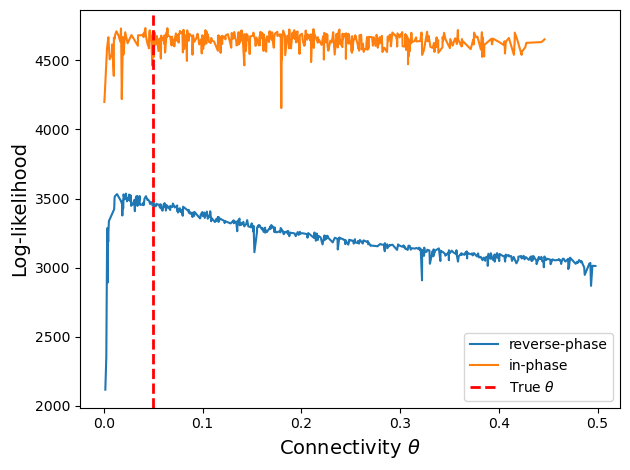

In [4]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from glob import glob

plt.close('all')
df = pd.concat([pd.read_csv(fname) for fname in glob("res/*.csv")])
df = df[["sync", "chain_number", "step_number", 'theta', 'fun']]
dd = df.query("step_number == -1")
dd = dd.sort_values(['sync', 'theta'])
dd['log-likelihood'] = -dd.fun
dd['synchronization'] = dd['sync'].map({True: 'in-phase', False: 'reverse-phase'})

plt.close('all')
sns.lineplot(data=dd.query('fun <0'), x='theta', y='log-likelihood', hue='synchronization')
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label=r'True $\theta$')
plt.xlabel(r"Connectivity $\theta$", fontsize=14)
plt.ylabel(r"Log-likelihood", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig("pix/likelihood_surface.png", dpi=150)
plt.savefig("pix/likelihood_surface.pdf")

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

def median_ratio(pp):
    """Calculate median ratio of sync/unsync CRLB"""
    sync = pp.query("phase2 == 0").crlb.values
    unsync = pp.query("phase2 > 0").crlb.values
    return np.median(sync) / np.median(unsync)

df = pd.read_csv("crlb.csv")
groups = list(df.groupby(['amplitude', 'theta']))

# Parallel computation
results = Parallel(n_jobs=-1)(delayed(median_ratio)(group) for name, group in groups)

# Reconstruct as Series with MultiIndex
index = pd.MultiIndex.from_tuples([name for name, group in groups], names=['amplitude', 'theta'])
agg = pd.Series(results, index=index)

90th percentile: 946.8


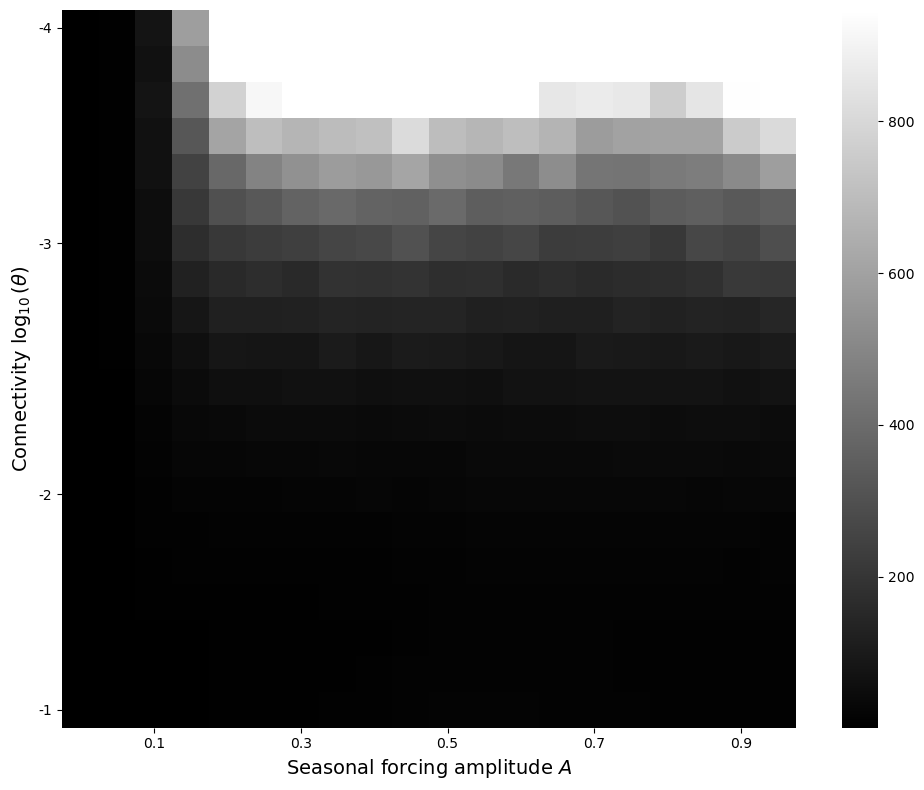

In [10]:
heat = agg.unstack(level='amplitude')
heat.index = np.log10(heat.index)

# Truncate at 90th percentile
vmax = np.percentile(heat.values.flatten(), 90)

plt.figure(figsize=(10, 8))
ax = sns.heatmap(heat, cmap='grey', xticklabels=False, yticklabels=False, vmin=1, vmax=vmax)

# Add contour line where ratio = 1
# Need to create meshgrid for contour (in heatmap coordinates)
#X, Y = np.meshgrid(np.arange(heat.shape[1]), np.arange(heat.shape[0]))
#ax.contour(X + 0.5, Y + 0.5, heat.values, levels=[1], colors='red', linewidths=2, label='20')

# Get the actual values for positioning
thetas = heat.index.values  # These are already log10(theta)
amplitudes = heat.columns.values

# Set x-ticks at positions corresponding to amplitudes 0.1, 0.3, 0.5, 0.7, 0.9
x_desired = [0.1, 0.3, 0.5, 0.7, 0.9]
x_positions = [np.argmin(np.abs(amplitudes - x)) + 0.5 for x in x_desired]
ax.set_xticks(x_positions)
ax.set_xticklabels(x_desired)

# Set y-ticks at positions corresponding to log10(theta) = -1, -2, -3, -4
y_desired = [-1, -2, -3, -4]
y_positions = [np.argmin(np.abs(thetas - y)) + 0.5 for y in y_desired]
ax.set_yticks(y_positions)
ax.set_yticklabels(y_desired)

plt.ylabel(r'Connectivity $\log_{10}(\theta)$', fontsize=14)
plt.xlabel(r'Seasonal forcing amplitude $A$', fontsize=14)
#plt.title(f'Median CRLB ratio (in-phase / reverse-phase), capped at 90th percentile ({vmax:.1f})', fontsize=12)
plt.tight_layout()
plt.savefig("pix/crlb_ratio.png", dpi=150)
plt.savefig("pix/crlb_ratio.pdf")
print(f"90th percentile: {vmax:.1f}")